# Linear Regression with PyTorch  
## A one-hour physics-first notebook

<div style="padding: 1rem; border-radius: 14px; background: linear-gradient(90deg, #eef6ff, #f8f2ff); border: 1px solid #d8e6ff;">
<b>Story for today:</b> we have a simple physics experiment. A spring is used as a force sensor. We stretch it, measure the force, and ask a neural-network style question:
<br><br>
<center><b>Can a machine learn the physical law from noisy experimental data?</b></center>
</div>

The model will be the simplest possible neural network:

$$
\hat y = wx + b.
$$

By the end, students should be able to connect:

- experimental data $\rightarrow$ tensors,
- physical model $\rightarrow$ linear layer,
- least squares $\rightarrow$ mean squared error,
- numerical optimization $\rightarrow$ gradient descent,
- PyTorch implementation $\rightarrow$ `nn.Linear`.

**Suggested timing:** 10 min data + model, 15 min loss/closed form, 20 min gradient descent, 15 min PyTorch implementation.


## 0. Setup

This notebook is intentionally independent of the `d2l` package. It only needs PyTorch, NumPy, and Matplotlib.


In [1]:
%matplotlib inline

import math
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibility
SEED = 5
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# A light plotting style for classroom use
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
})

print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.10.0+cpu


## 1. Physics example: calibrating a spring force sensor

Hooke's law says that the force is approximately proportional to the extension:

$$
F = kx.
$$

Real lab measurements are not perfect. A sensor may also have a small offset, so we use

$$
F = ax + b + \epsilon,
$$

where:

- $x$ is the spring extension in **cm**,
- $F$ is the measured force in **N**,
- $a$ is the slope in **N/cm**,
- $b$ is a small sensor offset,
- $\epsilon$ is experimental noise.

The true spring constant in SI units is

$$
k = 100a \quad \mathrm{N/m},
$$

because $1\,\mathrm{cm}=10^{-2}\,\mathrm{m}$.


In [2]:
# True experimental law, hidden from the learner
true_a = 0.42       # N/cm  -> 42 N/m
true_b = 0.15       # N
noise_sigma = 0.22  # N
n = 60

# Extension in cm
x = torch.linspace(0.5, 12.0, n).reshape(-1, 1)
y = true_a * x + true_b + noise_sigma * torch.randn(n, 1)

print("x shape:", tuple(x.shape))
print("y shape:", tuple(y.shape))
print(f"True slope a = {true_a:.3f} N/cm, true spring constant k = {100*true_a:.1f} N/m")
print(f"True offset b = {true_b:.3f} N")


x shape: (60, 1)
y shape: (60, 1)
True slope a = 0.420 N/cm, true spring constant k = 42.0 N/m
True offset b = 0.150 N


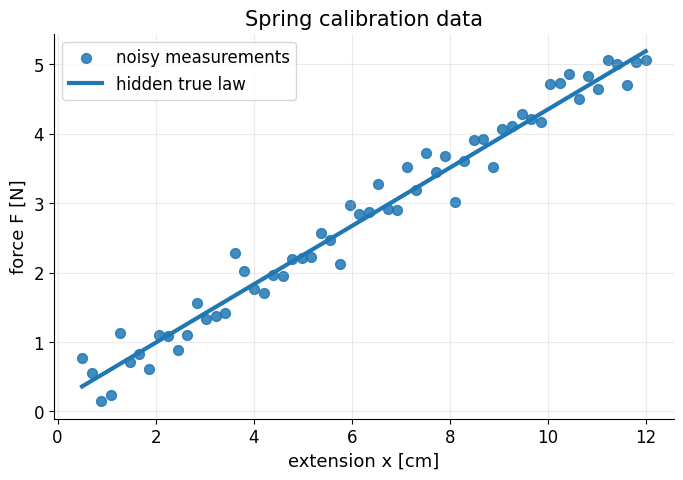

In [3]:
fig, ax = plt.subplots()
ax.scatter(x, y, s=50, alpha=0.85, label="noisy measurements")
ax.plot(x, true_a*x + true_b, linewidth=3, label="hidden true law")
ax.set_title("Spring calibration data")
ax.set_xlabel("extension x [cm]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 2. The linear regression model

We want to learn a function from data:

$$
x_i \longmapsto y_i.
$$

For one input variable, the model is

$$
\hat y_i = wx_i + b.
$$

For many input variables, the same idea becomes

$$
\hat y_i = \mathbf{x}_i^\top \mathbf{w} + b.
$$

In matrix notation for all data points at once:

$$
\hat{\mathbf y} = \mathbf X \mathbf w + b.
$$

This is already a tiny neural network: one linear layer with no activation function.


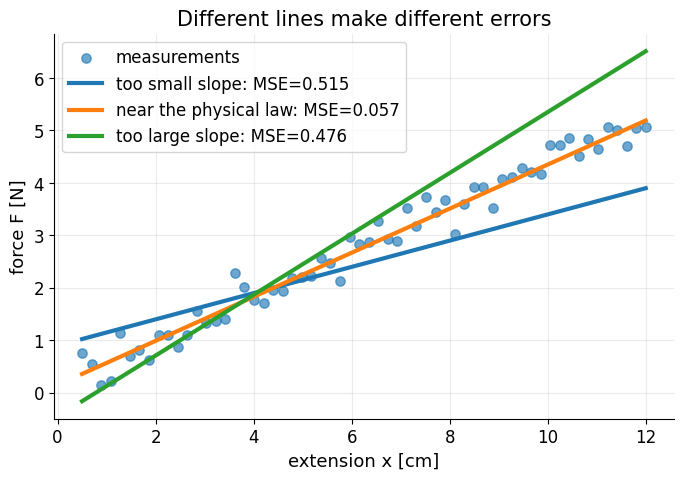

In [4]:
def predict(x, w, b):
    """Linear regression prediction: y_hat = wx + b."""
    return w * x + b

candidate_models = [
    (0.25, 0.90, "too small slope"),
    (0.42, 0.15, "near the physical law"),
    (0.58, -0.45, "too large slope"),
]

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, alpha=0.65, label="measurements")

for w, b, name in candidate_models:
    y_hat = predict(x, w, b)
    mse = torch.mean((y_hat - y)**2).item()
    ax.plot(x, y_hat, linewidth=3, label=f"{name}: MSE={mse:.3f}")

ax.set_title("Different lines make different errors")
ax.set_xlabel("extension x [cm]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 3. Loss function: how bad is a line?

For each measurement we define the residual

$$
r_i = \hat y_i - y_i.
$$

The standard loss for linear regression is the **mean squared error**:

$$
L(w,b) = \frac{1}{n}\sum_{i=1}^n \left(wx_i+b-y_i\right)^2.
$$

Why square the residuals?

1. positive and negative errors do not cancel,
2. large errors are punished more strongly,
3. the function is smooth and easy to differentiate.


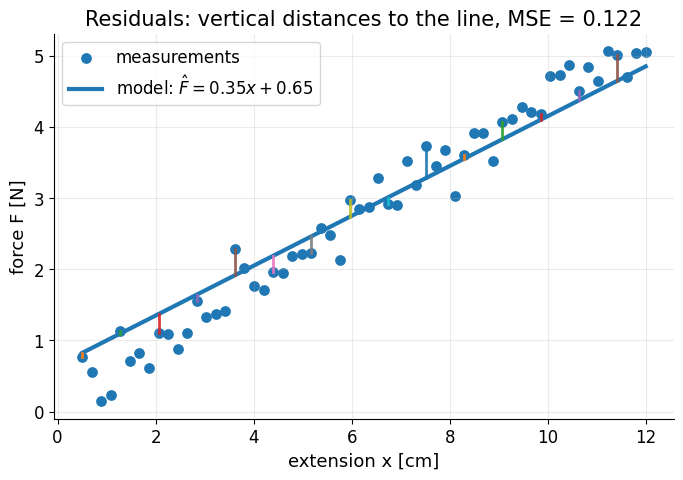

In [5]:
# Pick one candidate model and show its residuals
w_demo, b_demo = 0.35, 0.65
y_demo = predict(x, w_demo, b_demo)

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, label="measurements")
ax.plot(x, y_demo, linewidth=3, label=fr"model: $\hat F={w_demo:.2f}x+{b_demo:.2f}$")

# Draw a subset of residuals so the plot remains readable
for xi, yi, yhi in zip(x[::4], y[::4], y_demo[::4]):
    ax.plot([xi.item(), xi.item()], [yi.item(), yhi.item()], linewidth=2, alpha=0.9)

mse_demo = torch.mean((y_demo - y)**2).item()
ax.set_title(f"Residuals: vertical distances to the line, MSE = {mse_demo:.3f}")
ax.set_xlabel("extension x [cm]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 4. Classical least squares solution

Because the model is linear in its parameters, there is a classical numerical linear algebra solution.

Introduce the design matrix with a column of ones:

$$
\tilde{\mathbf X}=
\begin{bmatrix}
x_1 & 1\\
x_2 & 1\\
\vdots & \vdots\\
x_n & 1
\end{bmatrix},
\qquad
\boldsymbol{\theta}=
\begin{bmatrix}w\\b\end{bmatrix}.
$$

Then

$$
\hat{\mathbf y}=\tilde{\mathbf X}\boldsymbol{\theta}.
$$

The least-squares problem is

$$
\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}}
\left\|\tilde{\mathbf X}\boldsymbol{\theta}-\mathbf y\right\|_2^2.
$$

A stable way to compute it is to use `torch.linalg.lstsq` rather than explicitly forming
$(\tilde{\mathbf X}^\top\tilde{\mathbf X})^{-1}$.


Least-squares slope       w = 0.4248 N/cm
Least-squares intercept   b = 0.1395 N
Estimated spring constant k = 42.48 N/m
True spring constant      k = 42.00 N/m


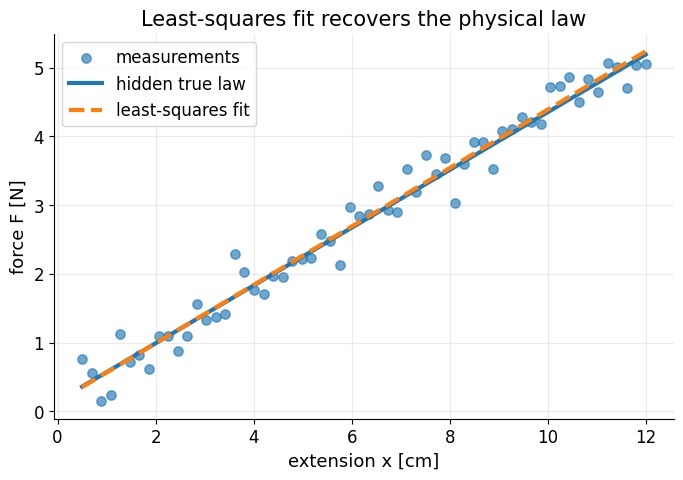

In [6]:
X_design = torch.cat([x, torch.ones_like(x)], dim=1)  # [x, 1]
solution = torch.linalg.lstsq(X_design, y).solution
w_lstsq, b_lstsq = solution[0, 0], solution[1, 0]

print(f"Least-squares slope       w = {w_lstsq.item():.4f} N/cm")
print(f"Least-squares intercept   b = {b_lstsq.item():.4f} N")
print(f"Estimated spring constant k = {100*w_lstsq.item():.2f} N/m")
print(f"True spring constant      k = {100*true_a:.2f} N/m")

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, alpha=0.65, label="measurements")
ax.plot(x, true_a*x + true_b, linewidth=3, label="hidden true law")
ax.plot(x, predict(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares fit")
ax.set_title("Least-squares fit recovers the physical law")
ax.set_xlabel("extension x [cm]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 5. Same problem, neural-network style: gradient descent

Deep learning usually does not solve a closed-form linear algebra problem. It minimizes a loss iteratively.

For linear regression,

$$
L(w,b)=\frac{1}{n}\sum_{i=1}^n(wx_i+b-y_i)^2.
$$

The gradients are

$$
\frac{\partial L}{\partial w}
=\frac{2}{n}\sum_{i=1}^n x_i(wx_i+b-y_i),
$$

$$
\frac{\partial L}{\partial b}
=\frac{2}{n}\sum_{i=1}^n(wx_i+b-y_i).
$$

Gradient descent updates the parameters by

$$
w \leftarrow w - \eta\frac{\partial L}{\partial w},
\qquad
b \leftarrow b - \eta\frac{\partial L}{\partial b},
$$

where $\eta$ is the learning rate.


In [7]:
# Compare manual gradients with PyTorch autograd at one arbitrary point
w = torch.tensor(0.10, requires_grad=True)
b = torch.tensor(1.00, requires_grad=True)

loss = torch.mean((predict(x, w, b) - y)**2)
loss.backward()

with torch.no_grad():
    residuals = predict(x, w, b) - y
    manual_dw = 2 * torch.mean(x * residuals)
    manual_db = 2 * torch.mean(residuals)

print(f"Autograd dL/dw = {w.grad.item(): .6f} | manual dL/dw = {manual_dw.item(): .6f}")
print(f"Autograd dL/db = {b.grad.item(): .6f} | manual dL/db = {manual_db.item(): .6f}")


Autograd dL/dw = -22.017366 | manual dL/dw = -22.017366
Autograd dL/db = -2.338593 | manual dL/db = -2.338593


In [8]:
def train_full_batch_gd(x, y, lr=0.015, epochs=500, w0=-0.05, b0=1.80):
    w = torch.tensor(float(w0), requires_grad=True)
    b = torch.tensor(float(b0), requires_grad=True)
    path = []

    for epoch in range(epochs):
        y_hat = predict(x, w, b)
        loss = torch.mean((y_hat - y)**2)
        loss.backward()

        with torch.no_grad():
            path.append((w.item(), b.item(), loss.item()))
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()

    return w.detach(), b.detach(), np.array(path)

w_gd, b_gd, path = train_full_batch_gd(x, y)

print(f"Gradient descent slope       w = {w_gd.item():.4f} N/cm")
print(f"Gradient descent intercept   b = {b_gd.item():.4f} N")
print(f"Estimated spring constant    k = {100*w_gd.item():.2f} N/m")
print(f"Final MSE                    L = {path[-1, 2]:.5f}")


Gradient descent slope       w = 0.4174 N/cm
Gradient descent intercept   b = 0.1991 N
Estimated spring constant    k = 41.74 N/m
Final MSE                    L = 0.05767


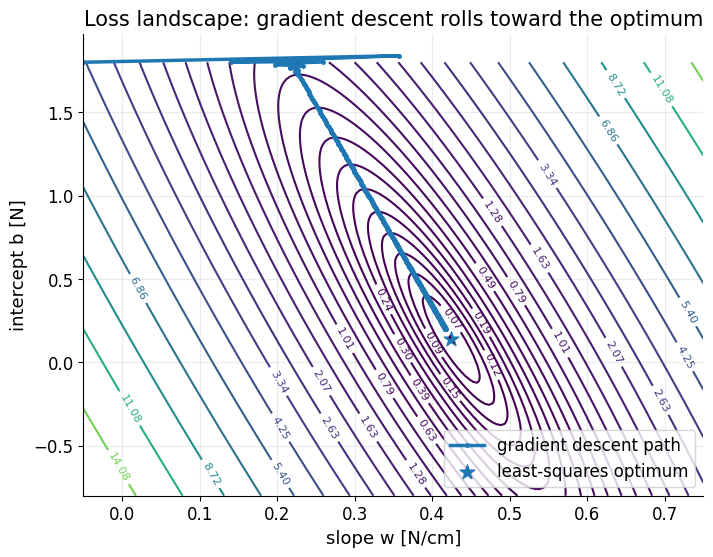

In [9]:
# Plot the loss surface and the path followed by gradient descent
w_values = torch.linspace(-0.05, 0.75, 160)
b_values = torch.linspace(-0.80, 1.80, 160)
W, B = torch.meshgrid(w_values, b_values, indexing="xy")

# Broadcast to compute the MSE at every point of the grid
Y_hat_grid = W[..., None] * x.flatten() + B[..., None]
Loss_grid = torch.mean((Y_hat_grid - y.flatten())**2, dim=-1)

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.geomspace(Loss_grid.min().item() + 1e-4, Loss_grid.max().item(), 25)
cs = ax.contour(W.numpy(), B.numpy(), Loss_grid.numpy(), levels=levels)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.plot(path[:, 0], path[:, 1], marker="o", markersize=2.5, linewidth=2.5, label="gradient descent path")
ax.scatter([w_lstsq.item()], [b_lstsq.item()], s=120, marker="*", label="least-squares optimum")
ax.set_title("Loss landscape: gradient descent rolls toward the optimum")
ax.set_xlabel("slope w [N/cm]")
ax.set_ylabel("intercept b [N]")
ax.legend()
plt.show()


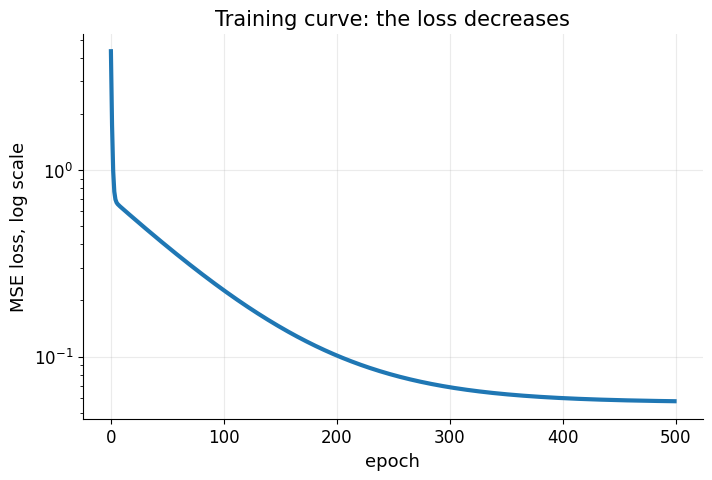

In [10]:
fig, ax = plt.subplots()
ax.plot(path[:, 2], linewidth=3)
ax.set_yscale("log")
ax.set_title("Training curve: the loss decreases")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss, log scale")
plt.show()


## 6. Why feature scaling matters

Physics students know this from numerical analysis: scaling can change the conditioning of a problem.

Here, $x$ is measured in cm and ranges roughly from $0$ to $12$. A common machine-learning preprocessing step is to standardize the input:

$$
z = \frac{x-\mu_x}{\sigma_x}.
$$

We train the model

$$
\hat y = w_z z + b_z.
$$

To convert back to physical units,

$$
\hat y = w_z\frac{x-\mu_x}{\sigma_x}+b_z
= \left(\frac{w_z}{\sigma_x}\right)x + \left(b_z - \frac{w_z\mu_x}{\sigma_x}\right).
$$

So the physical slope and intercept are

$$
w = \frac{w_z}{\sigma_x},
\qquad
b = b_z - \frac{w_z\mu_x}{\sigma_x}.
$$


In [11]:
x_mean = x.mean()
x_std = x.std()
z = (x - x_mean) / x_std

print(f"mean(x) = {x_mean.item():.3f} cm")
print(f"std(x)  = {x_std.item():.3f} cm")
print(f"mean(z) = {z.mean().item():.3f}")
print(f"std(z)  = {z.std().item():.3f}")


mean(x) = 6.250 cm
std(x)  = 3.404 cm
mean(z) = 0.000
std(z)  = 1.000


## 7. Linear regression from scratch with mini-batches

The basic training loop has five steps:

1. take a mini-batch of data,
2. compute predictions,
3. compute loss,
4. compute gradients with `loss.backward()`,
5. update parameters.

This is the same skeleton used later for MLPs and CNNs.


In [12]:
def data_iter(batch_size, features, labels):
    n = len(features)
    indices = torch.randperm(n)
    for i in range(0, n, batch_size):
        batch_indices = indices[i:i+batch_size]
        yield features[batch_indices], labels[batch_indices]

# Parameters in standardized coordinates: y_hat = w_z z + b_z
w_z = torch.normal(0, 0.01, size=(1, 1), requires_grad=True)
b_z = torch.zeros(1, requires_grad=True)

lr = 0.05
batch_size = 10
num_epochs = 30
loss_history = []

for epoch in range(num_epochs):
    for X_batch, y_batch in data_iter(batch_size, z, y):
        y_hat = X_batch @ w_z + b_z
        loss = torch.mean((y_hat - y_batch)**2)
        loss.backward()

        with torch.no_grad():
            w_z -= lr * w_z.grad
            b_z -= lr * b_z.grad
            w_z.grad.zero_()
            b_z.grad.zero_()

    with torch.no_grad():
        epoch_loss = torch.mean((z @ w_z + b_z - y)**2).item()
        loss_history.append(epoch_loss)

# Convert trained parameters back to physical units
w_physical = w_z.item() / x_std.item()
b_physical = b_z.item() - w_z.item() * x_mean.item() / x_std.item()

print(f"Learned w_z, b_z in standardized coordinates: {w_z.item():.4f}, {b_z.item():.4f}")
print(f"Converted slope       w = {w_physical:.4f} N/cm")
print(f"Converted intercept   b = {b_physical:.4f} N")
print(f"Estimated spring constant k = {100*w_physical:.2f} N/m")


Learned w_z, b_z in standardized coordinates: 1.4437, 2.8009
Converted slope       w = 0.4241 N/cm
Converted intercept   b = 0.1502 N
Estimated spring constant k = 42.41 N/m


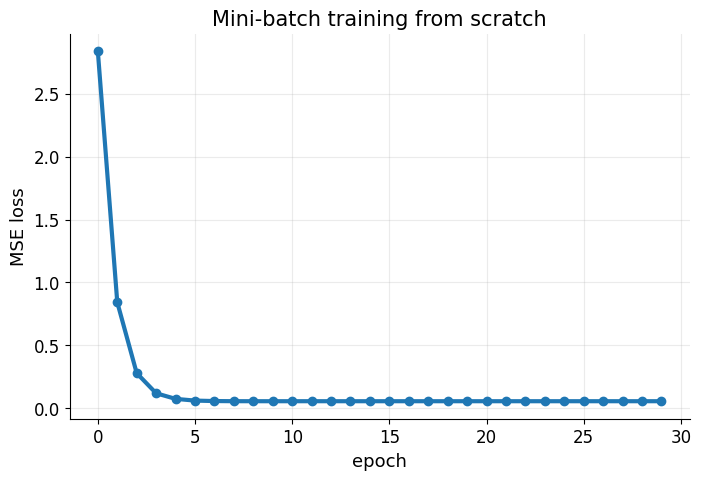

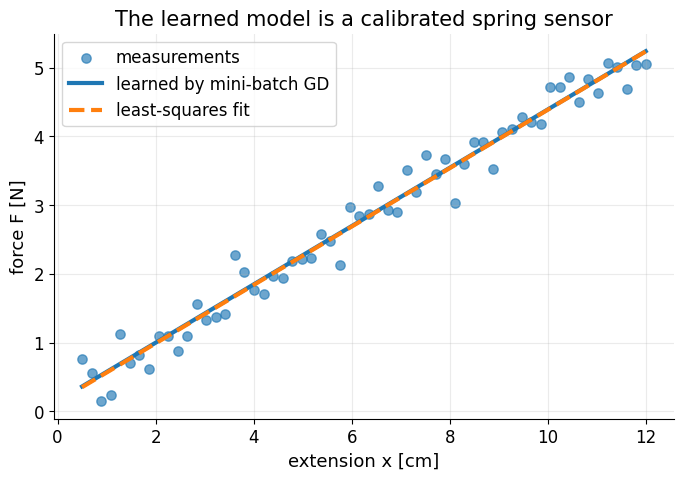

In [13]:
fig, ax = plt.subplots()
ax.plot(loss_history, marker="o", linewidth=3)
ax.set_title("Mini-batch training from scratch")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
plt.show()

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, alpha=0.65, label="measurements")
ax.plot(x, predict(x, w_physical, b_physical), linewidth=3, label="learned by mini-batch GD")
ax.plot(x, predict(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares fit")
ax.set_title("The learned model is a calibrated spring sensor")
ax.set_xlabel("extension x [cm]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 8. The concise PyTorch implementation

Now we write the same model using PyTorch building blocks:

- `TensorDataset` stores input-output pairs,
- `DataLoader` creates shuffled mini-batches,
- `nn.Linear(1, 1)` represents

$$
\hat y = wz + b,
$$

- `nn.MSELoss()` computes the mean squared error,
- `torch.optim.SGD` performs gradient descent.

This is the version students should recognize as the template for later neural networks.


In [14]:
dataset = TensorDataset(z, y)
loader = DataLoader(dataset, batch_size=10, shuffle=True)

model = nn.Linear(in_features=1, out_features=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

loss_history_pytorch = []

for epoch in range(30):
    for X_batch, y_batch in loader:
        y_hat = model(X_batch)
        loss = loss_fn(y_hat, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        epoch_loss = loss_fn(model(z), y).item()
        loss_history_pytorch.append(epoch_loss)

w_z_nn = model.weight.item()
b_z_nn = model.bias.item()
w_nn = w_z_nn / x_std.item()
b_nn = b_z_nn - w_z_nn * x_mean.item() / x_std.item()

print("PyTorch nn.Linear parameters")
print(f"standardized coordinates: w_z = {w_z_nn:.4f}, b_z = {b_z_nn:.4f}")
print(f"physical coordinates:     w = {w_nn:.4f} N/cm, b = {b_nn:.4f} N")
print(f"estimated spring constant: k = {100*w_nn:.2f} N/m")


PyTorch nn.Linear parameters
standardized coordinates: w_z = 1.4428, b_z = 2.7949
physical coordinates:     w = 0.4238 N/cm, b = 0.1459 N
estimated spring constant: k = 42.38 N/m


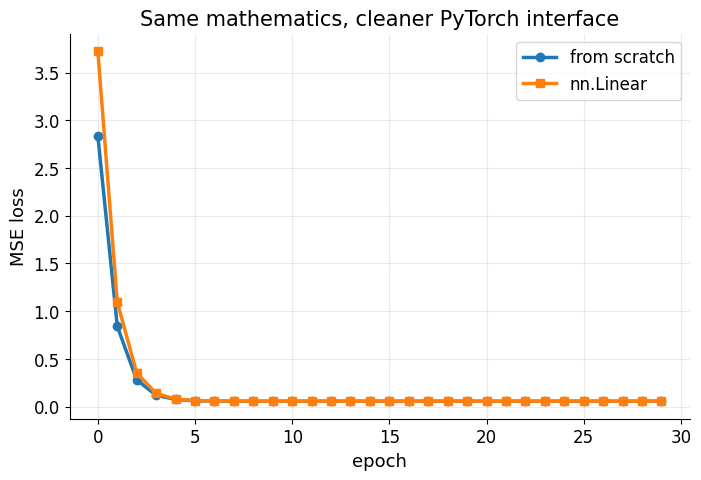

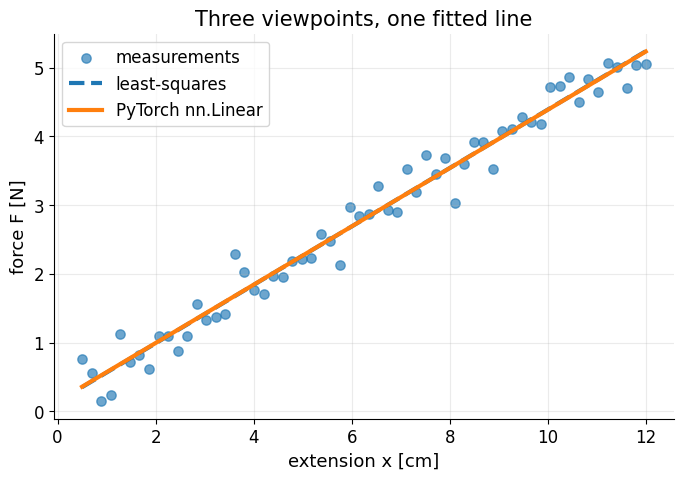

In [15]:
fig, ax = plt.subplots()
ax.plot(loss_history, marker="o", linewidth=2.5, label="from scratch")
ax.plot(loss_history_pytorch, marker="s", linewidth=2.5, label="nn.Linear")
ax.set_title("Same mathematics, cleaner PyTorch interface")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, alpha=0.65, label="measurements")
ax.plot(x, predict(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares")
ax.plot(x, predict(x, w_nn, b_nn), linewidth=3, label="PyTorch nn.Linear")
ax.set_title("Three viewpoints, one fitted line")
ax.set_xlabel("extension x [cm]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 9. From one input to many inputs

The one-dimensional model was

$$
\hat y = wx + b.
$$

With $d$ input features, the model is

$$
\hat y = \sum_{j=1}^d w_jx_j + b
= \mathbf{x}^\top\mathbf{w}+b.
$$

Example: suppose a force sensor also drifts with temperature. A simple calibration model could be

$$
F = a x + c(T-T_0) + b + \epsilon.
$$

Now the input vector is

$$
\mathbf{x} = \begin{bmatrix}x \\ T-T_0\end{bmatrix}.
$$


In [16]:
# Two-feature calibration: extension and temperature drift
m = 200
extension = 12 * torch.rand(m, 1)              # cm
temp_drift = 8 * (torch.rand(m, 1) - 0.5)      # degrees C relative to T0

true_w_multi = torch.tensor([[0.42], [0.035]]) # [N/cm, N/deg C]
true_b_multi = 0.15
X_multi = torch.cat([extension, temp_drift], dim=1)
y_multi = X_multi @ true_w_multi + true_b_multi + 0.18 * torch.randn(m, 1)

# Standardize each column
mu = X_multi.mean(dim=0, keepdim=True)
sigma = X_multi.std(dim=0, keepdim=True)
Z_multi = (X_multi - mu) / sigma

loader_multi = DataLoader(TensorDataset(Z_multi, y_multi), batch_size=32, shuffle=True)
model_multi = nn.Linear(2, 1)
opt = torch.optim.SGD(model_multi.parameters(), lr=0.08)
loss_fn = nn.MSELoss()

for epoch in range(80):
    for Xb, yb in loader_multi:
        loss = loss_fn(model_multi(Xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()

# Convert weights from standardized coordinates back to physical coordinates
w_z_multi = model_multi.weight.detach().reshape(2, 1)
b_z_multi = model_multi.bias.detach().item()
w_multi_physical = w_z_multi / sigma.reshape(2, 1)
b_multi_physical = b_z_multi - torch.sum(w_z_multi.reshape(-1) * mu.reshape(-1) / sigma.reshape(-1)).item()

print("True physical parameters:")
print(f"  extension coefficient      = {true_w_multi[0].item():.4f} N/cm")
print(f"  temperature coefficient    = {true_w_multi[1].item():.4f} N/°C")
print(f"  intercept                  = {true_b_multi:.4f} N")

print("\nLearned physical parameters:")
print(f"  extension coefficient      = {w_multi_physical[0].item():.4f} N/cm")
print(f"  temperature coefficient    = {w_multi_physical[1].item():.4f} N/°C")
print(f"  intercept                  = {b_multi_physical:.4f} N")


True physical parameters:
  extension coefficient      = 0.4200 N/cm
  temperature coefficient    = 0.0350 N/°C
  intercept                  = 0.1500 N

Learned physical parameters:
  extension coefficient      = 0.4157 N/cm
  temperature coefficient    = 0.0390 N/°C
  intercept                  = 0.1981 N


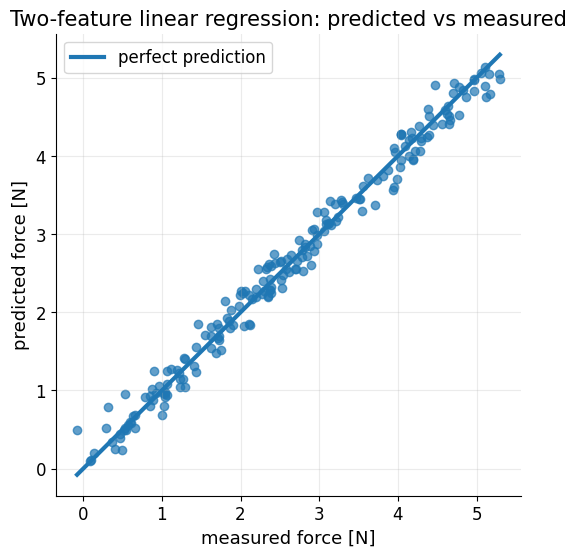

In [17]:
with torch.no_grad():
    y_pred_multi = model_multi(Z_multi)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_multi, y_pred_multi, alpha=0.7)
lims = [min(y_multi.min().item(), y_pred_multi.min().item()),
        max(y_multi.max().item(), y_pred_multi.max().item())]
ax.plot(lims, lims, linewidth=3, label="perfect prediction")
ax.set_title("Two-feature linear regression: predicted vs measured")
ax.set_xlabel("measured force [N]")
ax.set_ylabel("predicted force [N]")
ax.legend()
plt.show()


## 10. What students should remember

<div style="padding: 1rem; border-radius: 14px; background: #fff8e8; border: 1px solid #f1d08a;">
Linear regression is not just a statistics method. It is also the simplest trainable neural network layer.
</div>

The core concepts are:

1. **Model**

   $$
   \hat y = \mathbf{x}^\top\mathbf{w}+b.
   $$

2. **Loss**

   $$
   L=\frac{1}{n}\sum_i(\hat y_i-y_i)^2.
   $$

3. **Optimization**

   $$
   \theta \leftarrow \theta - \eta\nabla_\theta L.
   $$

4. **PyTorch training loop**

   ```python
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()
   ```

5. **Physical interpretation**

   The learned slope is not just a number. In this example it estimates the spring constant.


## 11. Short exercises for students

### Exercise 1 — Change the noise
Increase `noise_sigma` from `0.22` to `0.60`. What happens to the fitted line? What happens to the uncertainty you would expect in $k$?

### Exercise 2 — Bad learning rate
In the full-batch gradient descent section, try `lr=0.001`, `lr=0.015`, and `lr=0.03`. Which one is too slow? Which one is unstable?

### Exercise 3 — Units and scaling
Change the input from centimeters to meters. What happens to the numerical value of the slope? Does the physical spring constant change?

### Exercise 4 — Mini-batch size
Try batch sizes `1`, `10`, and `60`. Compare the training curves.

### Exercise 5 — Add a useless feature
Add a random feature to `X_multi`. Does the model learn a coefficient close to zero? Why might this fail for small datasets or large noise?
